# 📧 01 - Exploratory Data Analysis (EDA)

Khám phá và phân tích thống kê dữ liệu email spam theo yêu cầu đề bài:
- **1. Tải và kiểm tra tổng quan cấu trúc dữ liệu** (Shape, Schema, Missing values)
- **2. Phân tích phân bố nhãn mục tiêu** (Tỷ lệ lớp Ham vs Spam, đánh giá mức độ mất cân bằng nhãn)
- **3. Thống kê đặc trưng văn bản** (Độ dài email, số lượng từ, tần suất ký tự số, URLs, chữ in hoa)
- **4. Phân tích tần suất từ và ký tự đặc trưng** (Word frequency, Character frequency: dấu '!', '$', từ khóa nhạy cảm)
- **5. Trực quan hóa so sánh đặc trưng giữa Spam và Ham**


Notebook này **không gọi trực tiếp các model có sẵn** như `sklearn.linear_model`,
`sklearn.svm`, `sklearn.naive_bayes`, `sklearn.ensemble`, `sklearn.model_selection`
hoặc `sklearn.feature_extraction`.

Các thuật toán được gọi từ package tự xây dựng của project:

```text
src/
├── data/
├── features/
├── models/
├── evaluation/
└── deployment/
```

Các thư viện tính toán nền tảng (NumPy/Pandas/Scipy/Matplotlib...) nếu có được sử dụng
thì được **ẩn bên trong `src/`**, còn notebook chỉ làm việc với API của project.

## IMPORT THƯ VIỆN & CẤU HÌNH HỆ THỐNG:
- Thêm đường dẫn project root vào sys.path để import các module từ src/.
  
- Import pandas, numpy, matplotlib.pyplot, seaborn.
  
- Import các module: src.config, src.data.loader, src.evaluation.visualization.
  
- Thiết lập random_state=42 cố định kết quả.

## 1. Tải và kiểm tra tổng quan cấu trúc dữ liệu
- Gọi src.data.loader.load_raw_data() để đọc file data/raw/spam.csv.

- Chuẩn hóa 2 cột cốt lõi: label và text.

- Gọi src.data.loader.explore_raw_data(df) kiểm tra missing values, tổng số mẫu.

- Hiển thị 5 dòng đầu và 5 dòng cuối của dữ liệu.


In [3]:
import sys
from pathlib import Path

# Tìm thư mục gốc của project
PROJECT_ROOT = Path.cwd().resolve()

# Nếu notebook đang nằm trong thư mục notebooks thì lùi lên một cấp
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Kiểm tra thư mục src có tồn tại không
print("Thư mục gốc:", PROJECT_ROOT)
print("Có thư mục src:", (PROJECT_ROOT / "src").is_dir())

# Thêm thư mục gốc vào đường dẫn tìm kiếm của Python
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Thư mục gốc: D:\Machine Learning\SpamClassifier_My_Task1\spam_classifier-main
Có thư mục src: True


In [4]:
from src.evaluation.visualization import (
    plot_class_distribution,
    plot_text_length_distribution,
    plot_top_words,
)

print("Import thành công!")

Import thành công!


In [5]:
# chỉ import package tự xây dựng 
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_raw_data, explore_raw_data
from src.evaluation.visualization import plot_class_distribution, plot_text_length_distribution, plot_top_words
from pathlib import Path

df = load_raw_data(PROJECT_ROOT / "data" / "raw" / "spam.csv")
explore_raw_data(df)

print("Kích thước dữ liệu:", len(df))
print("\n5 dòng đầu tiên của dữ liệu:")
display(df[:5])
print("\n5 dòng cuối cùng của dữ liệu:")
display(df[-5:])

Kích thước dữ liệu: 43849

5 dòng đầu tiên của dữ liệu:


[{'source_id': 1,
  'label': 'ham',
  'text': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
  'raw_text': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'},
 {'source_id': 2,
  'label': 'ham',
  'text': 'Ok lar... Joking wif u oni...',
  'raw_text': 'Ok lar... Joking wif u oni...'},
 {'source_id': 3,
  'label': 'spam',
  'text': "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
  'raw_text': "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"},
 {'source_id': 4,
  'label': 'ham',
  'text': 'U dun say so early hor... U c already then say...',
  'raw_text': 'U dun say so early hor... U c already then say...'},
 {'source_id': 5,
  'label': 'ham',


5 dòng cuối cùng của dữ liệu:


[{'source_id': 43845,
  'label': 'ham',
  'text': '- - - - - - - - - - - - - - - - - - - - - - forwarded by ami chokshi / corp / enron on 10 / 06 / 2000\n04 : 22 pm - - - - - - - - - - - - - - - - - - - - - - - - - - -\ntroy _ a _ benoit @ reliantenergy . com on 10 / 06 / 2000 03 : 59 : 29 pm\nto : " ami chokshi "\ncc :\nsubject : revised\n( see attached file : hpl - oct . xls )\n- hpl - oct . xls',
  'raw_text': '- - - - - - - - - - - - - - - - - - - - - - forwarded by ami chokshi / corp / enron on 10 / 06 / 2000\n04 : 22 pm - - - - - - - - - - - - - - - - - - - - - - - - - - -\ntroy _ a _ benoit @ reliantenergy . com on 10 / 06 / 2000 03 : 59 : 29 pm\nto : " ami chokshi "\ncc :\nsubject : revised\n( see attached file : hpl - oct . xls )\n- hpl - oct . xls'},
 {'source_id': 43846,
  'label': 'ham',
  'text': 'fyi these are the standards we are putting out there for gcp worldwide\n( draft at the moment - - to initiate a debate )\nsome of the standards are quite " lofty " but i think we

In [6]:

import src.evaluation.visualization as viz

print("Python đang đọc file:", viz.__file__)
print("Các hàm hiện có:")

print([
    name for name in dir(viz)
    if name.startswith("plot_")
])

Python đang đọc file: D:\Machine Learning\SpamClassifier_My_Task1\spam_classifier-main\src\evaluation\visualization.py
Các hàm hiện có:
['plot_class_distribution', 'plot_confusion_matrix_heatmap', 'plot_eda_summary', 'plot_models_comparison_bar', 'plot_roc_and_pr_curves', 'plot_text_length_distribution', 'plot_top_words']


In [7]:
# chuẩn hóa 2 cột lable và text
if df and "v1" in df[0] and "label" not in df[0]:
    for row in df:
        row["label"] = row.pop("v1")
        row["text"] = row.pop("v2")
print("Các cột:", list(df[0].keys()) if df else [])
print("Số dòng:", len(df))
print("Missing theo cột:")
print({key: sum(not str(row.get(key) or "").strip() for row in df)
       for key in ("label", "text")})
print("\nPhân bố nhãn:")
print(dict.fromkeys(["ham", "spam"], 0) | {
    label: sum(row.get("label") == label for row in df)
    for label in ("ham", "spam")
})

Các cột: ['source_id', 'label', 'text', 'raw_text']
Số dòng: 43849
Missing theo cột:
{'label': 2192, 'text': 2192}

Phân bố nhãn:
{'ham': 22820, 'spam': 18834}


## 2. Phân tích phân bố nhãn (Target Class Distribution)

- Đếm số lượng mẫu của từng nhãn (df['label'].value_counts()).

- Tính tỷ lệ phần trăm (%) tương ứng của lớp Ham và lớp Spam.

- Vẽ biểu đồ Bar chart kết hợp Pie chart thể hiện mức độ mất cân bằng lớp.


In [8]:
# Đếm số lượng mẫu của từng nhãn
label_counts = {}
for row in df:
    label = row.get("label", "")
    label_counts[label] = label_counts.get(label, 0) + 1

# Tính tỷ lệ phần trăm
total = sum(label_counts.values())
label_ratio = {
    label: count / total * 100
    for label, count in label_counts.items()
} if total else {}

# Hiển thị số lượng mẫu
display([{"label": label, "count": count}
         for label, count in label_counts.items()])

# Hiển thị tỷ lệ phần trăm, làm tròn 2 chữ số
display([{"label": label, "percent": round(percent, 2)}
         for label, percent in label_ratio.items()])


[{'label': 'ham', 'count': 22820},
 {'label': 'spam', 'count': 18834},
 {'label': '', 'count': 2192},
 {'label': 'category', 'count': 1},
 {'label': 'label', 'count': 2}]

[{'label': 'ham', 'percent': 52.04},
 {'label': 'spam', 'percent': 42.95},
 {'label': '', 'percent': 5.0},
 {'label': 'category', 'percent': 0.0},
 {'label': 'label', 'percent': 0.0}]

In [9]:
print("Kiểu dữ liệu:", type(df))
print("Số lượng phần tử:", len(df))
print("Phần tử đầu tiên:", df[0])

Kiểu dữ liệu: <class 'list'>
Số lượng phần tử: 43849
Phần tử đầu tiên: {'source_id': 1, 'label': 'ham', 'text': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...', 'raw_text': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'}


In [10]:
import pandas as pd

df = pd.DataFrame(df)

print("Kiểu dữ liệu:", type(df))
print("Kích thước:", df.shape)
print("Các cột:", df.columns.tolist())
print(df.head())

Kiểu dữ liệu: <class 'pandas.core.frame.DataFrame'>
Kích thước: (43849, 4)
Các cột: ['source_id', 'label', 'text', 'raw_text']
   source_id label                                               text  \
0          1   ham  Go until jurong point, crazy.. Available only ...   
1          2   ham                      Ok lar... Joking wif u oni...   
2          3  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3          4   ham  U dun say so early hor... U c already then say...   
4          5   ham  Nah I don't think he goes to usf, he lives aro...   

                                            raw_text  
0  Go until jurong point, crazy.. Available only ...  
1                      Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup fina...  
3  U dun say so early hor... U c already then say...  
4  Nah I don't think he goes to usf, he lives aro...  


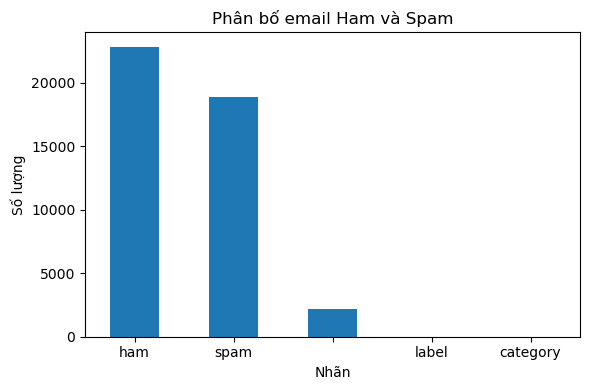

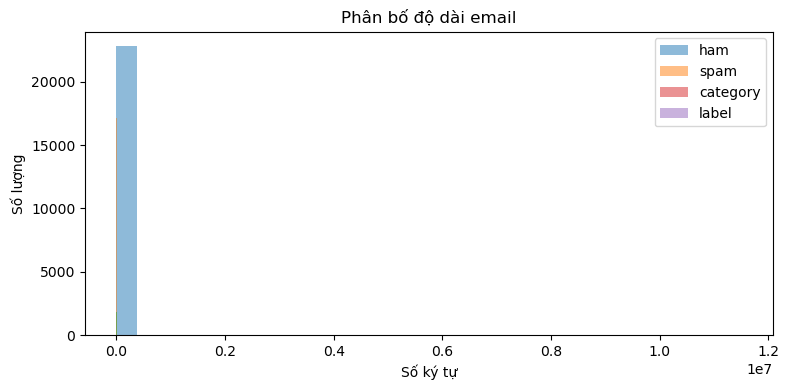

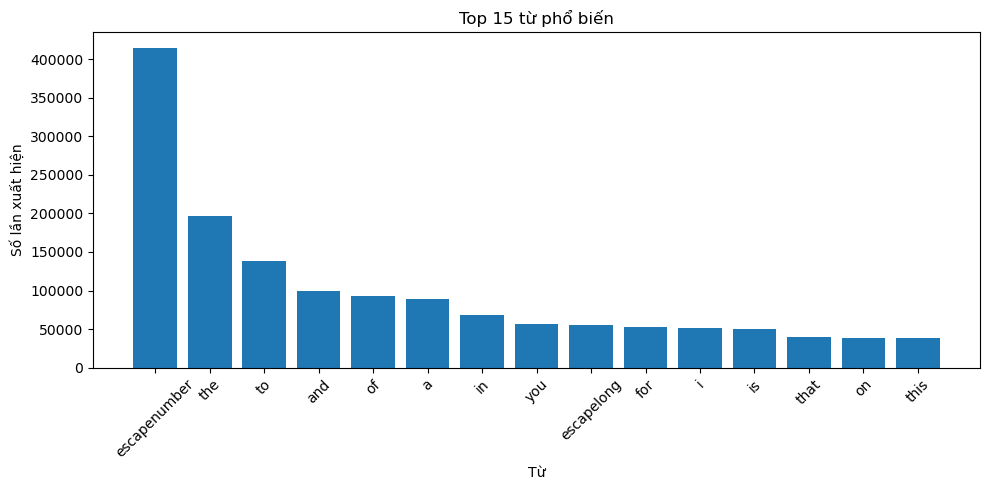

,word,count
0,escapenumber,413961
1,the,196359
2,to,138690
3,and,99070
4,of,93199
5,a,89495
6,in,68579
7,you,56221
8,escapelong,55056
9,for,53416


In [11]:
plot_class_distribution(df)
plot_text_length_distribution(df)
plot_top_words(df, top_n=15)

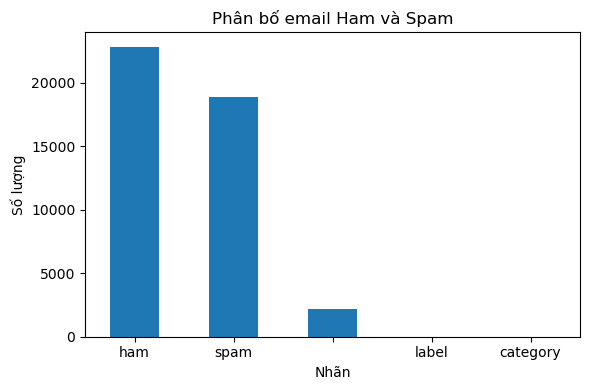

In [12]:
# Vẽ biểu đồ phân bố 
plot_class_distribution(df)

## 3. Thống kê đặc trưng văn bản & độ dài email

- Tính độ dài ký tự và số lượng từ của từng email.
  
- Đếm số lượng chữ cái in hoa và tính tỷ lệ chữ hoa / tổng số chữ cái.
  
- Đếm tần suất ký tự đặc biệt (dấu chấm than '!', ký hiệu tiền tệ '$', chữ số).
  
- So sánh trung bình các đặc trưng này giữa nhóm Spam và nhóm Ham.
  
- Vẽ biểu đồ Histogram/KDE so sánh độ dài email giữa hai lớp.

In [13]:

text_stats = []

for _, row in df.iterrows():
    text = str(row.get("text") or "")

    text_stats.append({
        "label": row.get("label", ""),
        "char_length": len(text),
        "word_count": len(text.split())
    })

text_stats_df = pd.DataFrame(text_stats)

print(text_stats_df.head())
print("Số dòng thống kê:", len(text_stats_df))

  label  char_length  word_count
0   ham          111          20
1   ham           29           6
2  spam          155          28
3   ham           49          11
4   ham           61          13
Số dòng thống kê: 43849


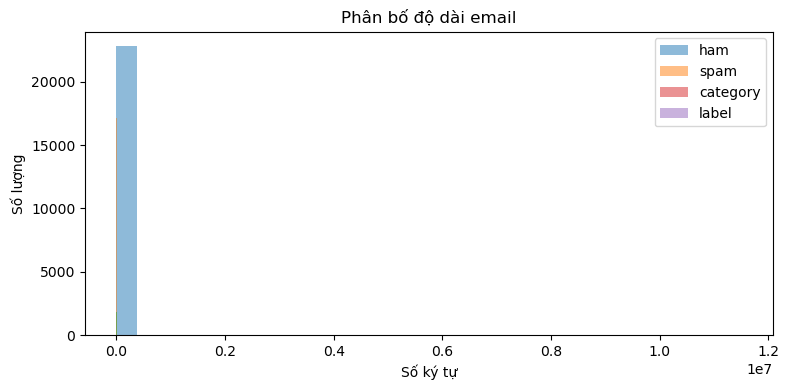

In [14]:
# Vẽ Histogram/KDE so sánh độ dài email giữa Spam và Ham
plot_text_length_distribution(df)

## 4. Phân tích tần suất từ vựng (Word Frequency & Keywords)

- Tách từ và đếm Top 20 từ xuất hiện nhiều nhất trong email Spam (free, claim, win, urgent, v.v.).
  
- Tách từ và đếm Top 20 từ xuất hiện nhiều nhất trong email Ham.
  
- Vẽ biểu đồ Bar chart nằm ngang so sánh Top từ khóa giữa 2 nhóm.

In [15]:
import os

print("Thư mục hiện tại:", os.getcwd())
print("Các thư mục và file:", os.listdir())

Thư mục hiện tại: d:\Machine Learning\SpamClassifier_My_Task1\spam_classifier-main\notebooks
Các thư mục và file: ['.ipynb_checkpoints', '01_eda.ipynb', '02_preprocessing_and_features.ipynb', '03_model_baseline_and_training.ipynb', '04_tuning_and_ensemble.ipynb', '05_error_analysis_and_deployment.ipynb', 'README.md']


In [17]:
import os
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\hop98\Documents\Huyền\SpamClassifier_My_Task1\spam_classifier-main"
)

# Tìm lại project root an toàn

base_candidates = [
    PROJECT_ROOT,
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
]

PROJECT_ROOT = next(
    (
        p.resolve()
        for p in base_candidates
        if p is not None and p.exists() and (p / "src").exists()
    ),
    PROJECT_ROOT.resolve() if PROJECT_ROOT and PROJECT_ROOT.exists() and (PROJECT_ROOT / "src").exists() else None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Không tìm thấy thư mục project root. Kiểm tra lại đường dẫn notebook/project.")

# Chuyển cwd về project root và thêm vào sys.path để import src.* hoạt động
os.chdir(PROJECT_ROOT)

print("Thư mục hiện tại:", os.getcwd())
print("Có thư mục src không:", (PROJECT_ROOT / "src").exists())

Thư mục hiện tại: D:\Machine Learning\SpamClassifier_My_Task1\spam_classifier-main
Có thư mục src không: True


In [18]:
import sys
import importlib

sys.path.insert(0, str(PROJECT_ROOT))

import src.evaluation.visualization as viz

importlib.reload(viz)
plot_top_words = viz.plot_top_words

In [19]:
import inspect

print(inspect.signature(plot_top_words))

(df, text_col='text', label_col='label', top_n=15, save_path=None, label=None)


In [27]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(
    r"D:\Machine Learning\SpamClassifier_My_Task1\spam_classifier-main"
)
print("Có thư mục src không:", (PROJECT_ROOT / "src").exists())

# Đọc dữ liệu từ package của project
from src.data.loader import load_raw_data

df = load_raw_data(PROJECT_ROOT / "data" / "raw" / "spam.csv")
df = pd.DataFrame(df)
print("Kích thước dữ liệu:", df.shape)
print("Các cột:", df.columns.tolist())
display(df.head())

Có thư mục src không: True
Kích thước dữ liệu: (43849, 4)
Các cột: ['source_id', 'label', 'text', 'raw_text']


,source_id,label,text,raw_text
0,1,ham,"Go until jurong point, crazy.. Available only ...","Go until jurong point, crazy.. Available only ..."
1,2,ham,Ok lar... Joking wif u oni...,Ok lar... Joking wif u oni...
2,3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,4,ham,U dun say so early hor... U c already then say...,U dun say so early hor... U c already then say...
4,5,ham,"Nah I don't think he goes to usf, he lives aro...","Nah I don't think he goes to usf, he lives aro..."


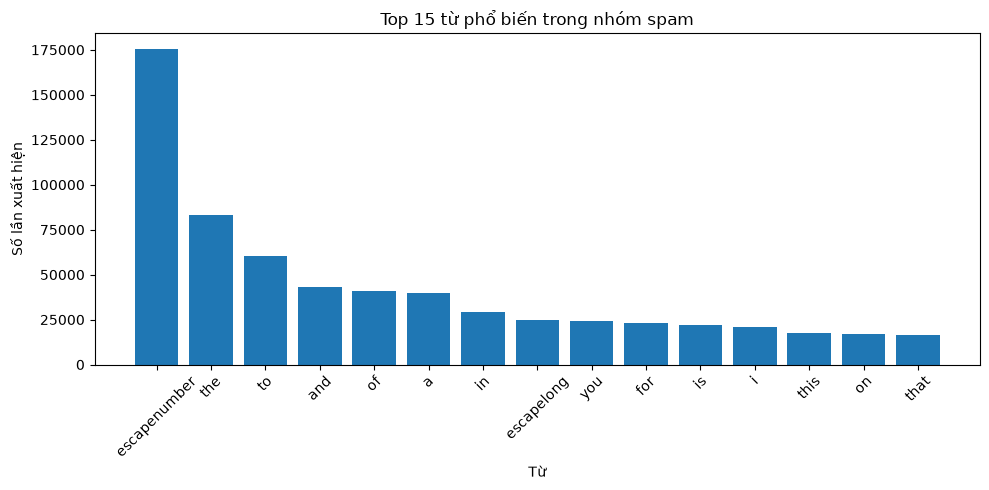

In [ ]:
spam_words = plot_top_words(
    df,
    text_col="text",
    label_col="label",
    top_n=15,
    label="spam"
)